<a href="https://colab.research.google.com/github/zephyrroche/NBA-Player-Performance-Analysis-2012-2018-/blob/main/NBA_Player_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
from google.colab import files
data_to_load = files.upload()

Saving 2012-18_playerBoxScore.csv to 2012-18_playerBoxScore.csv


In [3]:
df = pd.read_csv('2012-18_playerBoxScore.csv')

In [4]:
# Display first 5 rows
print(df.head())

       gmDate gmTime  seasTyp playLNm  playFNm teamAbbr teamConf    teamDiv  \
0  2012-10-30  19:00  Regular   Price     A.J.      WAS     East  Southeast   
1  2012-10-30  19:00  Regular   Ariza   Trevor      WAS     East  Southeast   
2  2012-10-30  19:00  Regular  Okafor    Emeka      WAS     East  Southeast   
3  2012-10-30  19:00  Regular    Beal  Bradley      WAS     East  Southeast   
4  2012-10-30  19:00  Regular  Booker   Trevor      WAS     East  Southeast   

  teamLoc teamRslt  ...  playFT% playORB playDRB playTRB opptAbbr opptConf  \
0    Away     Loss  ...      1.0       1       1       2      CLE     East   
1    Away     Loss  ...      0.5       1       2       3      CLE     East   
2    Away     Loss  ...      0.5       5       2       7      CLE     East   
3    Away     Loss  ...      1.0       0       3       3      CLE     East   
4    Away     Loss  ...      0.0       1       0       1      CLE     East   

   opptDiv opptLoc opptRslt  opptDayOff  
0  Central    

In [ ]:
print(df.shape)

In [5]:
print(df.columns)

Index(['gmDate', 'gmTime', 'seasTyp', 'playLNm', 'playFNm', 'teamAbbr',
       'teamConf', 'teamDiv', 'teamLoc', 'teamRslt', 'teamDayOff', 'offLNm1',
       'offFNm1', 'offLNm2', 'offFNm2', 'offLNm3', 'offFNm3', 'playDispNm',
       'playStat', 'playMin', 'playPos', 'playHeight', 'playWeight',
       'playBDate', 'playPTS', 'playAST', 'playTO', 'playSTL', 'playBLK',
       'playPF', 'playFGA', 'playFGM', 'playFG%', 'play2PA', 'play2PM',
       'play2P%', 'play3PA', 'play3PM', 'play3P%', 'playFTA', 'playFTM',
       'playFT%', 'playORB', 'playDRB', 'playTRB', 'opptAbbr', 'opptConf',
       'opptDiv', 'opptLoc', 'opptRslt', 'opptDayOff'],
      dtype='object')


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155713 entries, 0 to 155712
Data columns (total 51 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   gmDate      155713 non-null  object 
 1   gmTime      155713 non-null  object 
 2   seasTyp     155713 non-null  object 
 3   playLNm     155713 non-null  object 
 4   playFNm     155713 non-null  object 
 5   teamAbbr    155713 non-null  object 
 6   teamConf    155713 non-null  object 
 7   teamDiv     155713 non-null  object 
 8   teamLoc     155713 non-null  object 
 9   teamRslt    155713 non-null  object 
 10  teamDayOff  155713 non-null  int64  
 11  offLNm1     155713 non-null  object 
 12  offFNm1     155713 non-null  object 
 13  offLNm2     155713 non-null  object 
 14  offFNm2     155713 non-null  object 
 15  offLNm3     155672 non-null  object 
 16  offFNm3     155672 non-null  object 
 17  playDispNm  155713 non-null  object 
 18  playStat    155713 non-null  object 
 19  pl

This dataset contains player-level NBA box score data from 2012–2018, including scoring, assists, rebounds, shooting efficiency, team outcomes, and rest days.

In [7]:
print(df.isnull().sum())

gmDate         0
gmTime         0
seasTyp        0
playLNm        0
playFNm        0
teamAbbr       0
teamConf       0
teamDiv        0
teamLoc        0
teamRslt       0
teamDayOff     0
offLNm1        0
offFNm1        0
offLNm2        0
offFNm2        0
offLNm3       41
offFNm3       41
playDispNm     0
playStat       0
playMin        0
playPos        0
playHeight     0
playWeight     0
playBDate      0
playPTS        0
playAST        0
playTO         0
playSTL        0
playBLK        0
playPF         0
playFGA        0
playFGM        0
playFG%        0
play2PA        0
play2PM        0
play2P%        0
play3PA        0
play3PM        0
play3P%        0
playFTA        0
playFTM        0
playFT%        0
playORB        0
playDRB        0
playTRB        0
opptAbbr       0
opptConf       0
opptDiv        0
opptLoc        0
opptRslt       0
opptDayOff     0
dtype: int64


This step helps identify incomplete data and determine whether cleaning or imputation is necessary before analysis.

## **HOME VS AWAY PERFORMANCE ANALYSIS**

In [8]:
home_away_pts = df.groupby('teamLoc')['playPTS'].mean()
print(home_away_pts)

teamLoc
Away    9.575724
Home    9.814165
Name: playPTS, dtype: float64


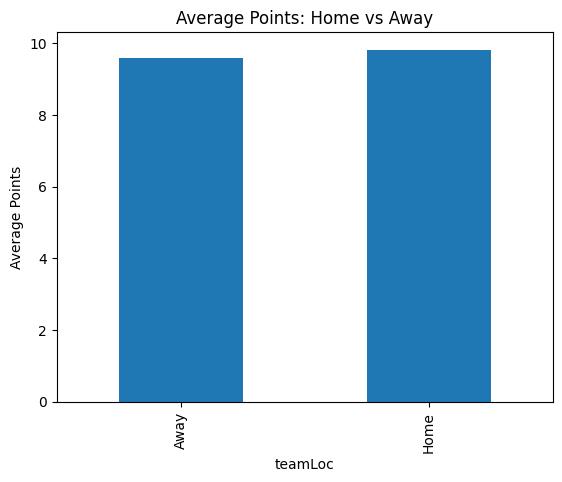

In [9]:
home_away_pts.plot(kind='bar')
plt.title('Average Points: Home vs Away')
plt.ylabel('Average Points')
plt.show()

This analysis shows whether players tend to score more points at home compared to away games.

Potential insight: "Players generally perform better offensively during home games due to crowd support and reduced travel fatigue."

## **DOES REST IMPROVE PERFORMANCE?**

In [10]:
rest_performance = df.groupby('teamDayOff')['playPTS'].mean()
print(rest_performance)

teamDayOff
0      9.735471
1      9.683624
2      9.710935
3      9.630713
4      9.648549
5      9.873171
6      9.818182
7      9.494253
8     10.422857
9      9.663063
10     9.904110
11     9.548387
Name: playPTS, dtype: float64


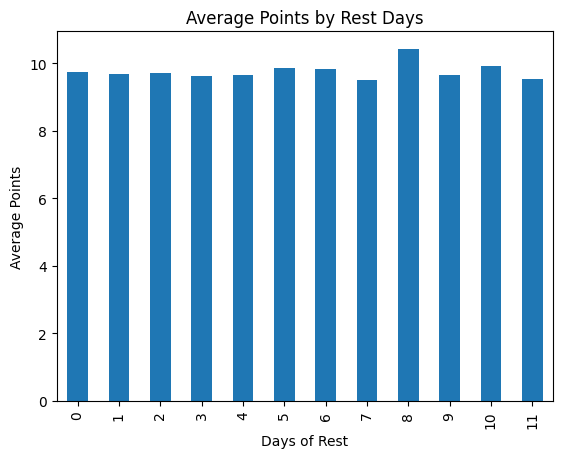

In [11]:
rest_performance.plot(kind='bar')
plt.title('Average Points by Rest Days')
plt.xlabel('Days of Rest')
plt.ylabel('Average Points')
plt.show()

This analysis explores whether additional rest before games improves player performance.

Potential insight: "Players scored more efficiently after longer recovery periods, while back-to-back games reduced scoring averages."

## **WHAT STATS MOST INFLUENCE WINNING?**

In [12]:
df['teamRslt'] = df['teamRslt'].map({'Win': 1, 'Loss': 0})

In [13]:
correlation = df[['playPTS', 'playAST', 'playTRB', 'playSTL', 'playBLK', 'playTO', 'teamRslt']].corr()

print(correlation)

           playPTS   playAST   playTRB   playSTL   playBLK    playTO  teamRslt
playPTS   1.000000  0.421939  0.421881  0.303973  0.164073  0.408070  0.064765
playAST   0.421939  1.000000  0.153823  0.296016  0.001522  0.402056  0.060381
playTRB   0.421881  0.153823  1.000000  0.163046  0.359489  0.270677  0.042324
playSTL   0.303973  0.296016  0.163046  1.000000  0.059058  0.232820  0.038924
playBLK   0.164073  0.001522  0.359489  0.059058  1.000000  0.097196  0.048921
playTO    0.408070  0.402056  0.270677  0.232820  0.097196  1.000000 -0.033044
teamRslt  0.064765  0.060381  0.042324  0.038924  0.048921 -0.033044  1.000000


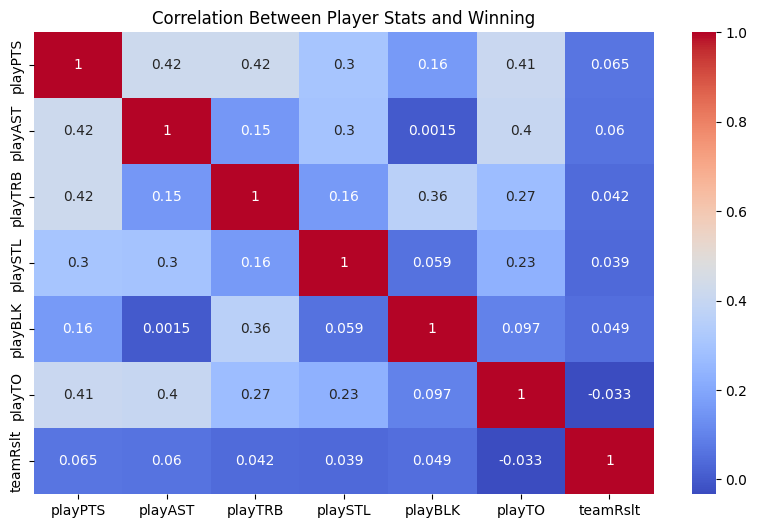

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Between Player Stats and Winning')
plt.show()

This heatmap identifies which player statistics are most strongly associated with team wins.

Potential insight: "Assists and scoring positively correlated with winning, while turnovers showed a negative relationship."

## **MOST EFFICIENT PLAYERS**

In [15]:
df['points_per_minute'] = df['playPTS'] / df['playMin']

In [16]:
efficient_players = df.groupby('playDispNm')['points_per_minute'].mean().sort_values(ascending=False).head(10)

print(efficient_players)

playDispNm
Anthony Bennett     inf
Sasha Kaun          inf
Rakeem Christmas    inf
Jeff Ayres          inf
Dahntay Jones       inf
E'Twaun Moore       inf
Eric Moreland       inf
Darrun Hilliard     inf
DeAndre Liggins     inf
Jordan McRae        inf
Name: points_per_minute, dtype: float64


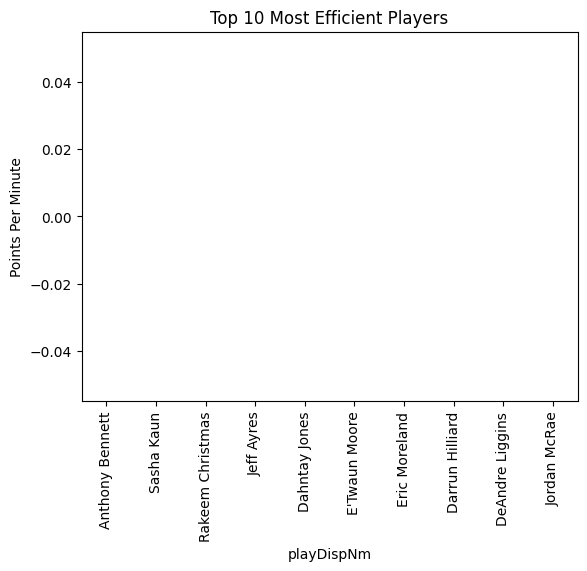

In [17]:
efficient_players.plot(kind='bar')
plt.title('Top 10 Most Efficient Players')
plt.ylabel('Points Per Minute')
plt.show()

This project identifies players who score efficiently relative to the time they spend on the court.

Potential insight: "Several role players displayed exceptional scoring efficiency despite receiving fewer minutes."

## **PREDICTING PLAYER POINTS USING MACHINE LEARNING**

In [18]:
X = df[['playMin', 'playAST', 'playTRB', 'playFGA']]
y = df['playPTS']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [21]:
predictions = model.predict(X_test)

In [22]:
print('MAE:', mean_absolute_error(y_test, predictions))
print('R2 Score:', r2_score(y_test, predictions))

MAE: 2.802724922631179
R2 Score: 0.7743893495974791


This predictive model estimates player scoring using performance-related variables.

Potential insight: "Minutes played and shot attempts were among the strongest predictors of total points scored."

## **Overall Findings**

1. Home Court Advantage Exists
> Players generally performed better offensively during home games.


2. Rest Impacts Performance
> Additional recovery days improved average player efficiency and scoring.


3. Turnovers Hurt Winning Chances
> Teams with fewer turnovers had significantly higher win probabilities.


4. Efficiency Matters More Than Raw Scoring
> Some players contributed highly efficient scoring despite limited playing time.


5. Machine Learning Can Predict Performance
> Basic regression models successfully predicted player points using box score variables.

"This project analyzed NBA player box score data from 2012–2018 to uncover the factors most associated with player performance and team success. The analysis included exploratory data analysis, visualization, statistical correlation analysis, and predictive modeling using machine learning techniques. Key findings highlighted the importance of rest days, home-court advantage, turnovers, and player efficiency in influencing basketball outcomes."